<img src="../../../assets/images/logos/ucu_logo_clean.svg" alt="University Logo" style="float: right; width: 200px;">

### Matemática para Aprendizaje Automático 2025
#### Universidad Católica del Uruguay

### Laboratorio 2.3: Sistemas Lineales y Mínimos Cuadrados

#### Introducción

En este laboratorio exploraremos la resolución de sistemas lineales y especialmente la aplicación del método de mínimos cuadrados. Estudiaremos el comportamiento de diferentes funciones para trabajar con distintos tipos de sistemas (cuadrados, sobredeterminados, subdeterminados) y aplicaremos estos conceptos para ajustar modelos a datos.

#### Solución de sistemas lineales
En esta sección veremos cómo resolver sistemas lineales utilizando diferentes métodos. Nos enfocaremos en las funciones `np.linalg.solve()`, `np.linalg.lstsq()` y `np.linalg.pinv()`. 

`solve()` es la función más común para resolver sistemas lineales compatibles determinados, pero tiene limitaciones. `pinv()` calcula la pseudoinversa de una matriz, por lo que puede utilizarse para resolver sistemas generales como fue visto en clase.  La función `lstsq()` es similar a `solve()` en su sintaxis, pero admite matrices no cuadradas.  En sistemas sobredeterminados, `lstsq()` encuentra la solución que minimiza el error cuadrático. En sistemas subdeterminados, `lstsq()` devuelve la solución de mínima norma.

##### Limitaciones de solve() y alternativas

**Ejercicio L2.3.1**: Considera los sistemas dados abajo. Verifica que `np.linalg.solve()` falla para matrices no cuadradas y para matrices singulares, pero funciona para matrices cuadradas invertibles. Averigua qué algoritmo usa `solve()` y justifica por qué no funciona para matrices no cuadradas o singulares.

**Ejercicio  L2.3.2**: Verifica que tanto `np.linalg.lstsq()` y `pinv()` pueden utilizarse para hallar soluciones para todos los sistemas dados. Compara los resultados y tiempos de ejecución entre ambas y con `solve()` en el caso aplicable.

### Recursos necesarios

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import timeit
import pandas as pd

In [7]:

# Matrices de prueba
matrices = {
    'Cuadrada invertible': np.array([[3, 1], [1, 2]]),
    'Cuadrada singular': np.array([[1, 2], [2, 4]]),
    'Rectangular alta': np.array([[2, 0], [1, 1], [0, 2]]),
    'Rectangular ancha': np.array([[1, 2, 3], [1, 0, 2]])
}

vectores = {
    'Cuadrada invertible': np.array([1, 1]),
    'Cuadrada singular': np.array([1, 1]),
    'Rectangular alta': np.array([0, 1, 1]),
    'Rectangular ancha': np.array([1, 2])
}

# solve() usa descomposicion LU (internamente LAPACK gesv).
# LU requiere una matriz cuadrada. Si la matriz es singular, el pivote se anula y falla.
# Para matrices no cuadradas lanza ValueError; para singulares, LinAlgError.

for m in matrices:
    print(f"Ejemplo: {m}")
    A = matrices[m]
    b = vectores[m]
    solution_solve = None

    # Resolucion con solve()
    try:
        solution_solve = np.linalg.solve(A, b)
        print(f"  solve():  {solution_solve}")
    except np.linalg.LinAlgError as e:
        print(f"  solve() fallo (singular):    {e}")
    except ValueError as e:
        print(f"  solve() fallo (no cuadrada): {e}")

    # Resolucion con lstsq()
    solution_lstsq, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    print(f"  lstsq():  {solution_lstsq}")

    # Resolucion con pinv()
    solution_pinv = np.linalg.pinv(A) @ b
    print(f"  pinv():   {solution_pinv}")

    # Comparacion de resultados numericos
    if solution_solve is not None:
        print(f"  solve == lstsq: {np.allclose(solution_solve, solution_lstsq)}")
        print(f"  solve == pinv:  {np.allclose(solution_solve, solution_pinv)}")
    print(f"  lstsq == pinv:  {np.allclose(solution_lstsq, solution_pinv)}")

    # Tiempos de ejecucion
    if solution_solve is not None:
        t_solve = timeit.timeit(lambda: np.linalg.solve(A, b), number=1000)
        print(f"  Tiempo solve:  {t_solve:.5f}s (1000 iter)")
    t_lstsq = timeit.timeit(lambda: np.linalg.lstsq(A, b, rcond=None), number=1000)
    t_pinv  = timeit.timeit(lambda: np.linalg.pinv(A) @ b, number=1000)
    print(f"  Tiempo lstsq:  {t_lstsq:.5f}s (1000 iter)")
    print(f"  Tiempo pinv:   {t_pinv:.5f}s (1000 iter)")
    print()


Ejemplo: Cuadrada invertible
  solve():  [0.2 0.4]
  lstsq():  [0.2 0.4]
  pinv():   [0.2 0.4]
  solve == lstsq: True
  solve == pinv:  True
  lstsq == pinv:  True
  Tiempo solve:  0.00600s (1000 iter)
  Tiempo lstsq:  0.01366s (1000 iter)
  Tiempo pinv:   0.03533s (1000 iter)

Ejemplo: Cuadrada singular
  solve() fallo (singular):    Singular matrix
  lstsq():  [0.12 0.24]
  pinv():   [0.12 0.24]
  lstsq == pinv:  True
  Tiempo lstsq:  0.01241s (1000 iter)
  Tiempo pinv:   0.03008s (1000 iter)

Ejemplo: Rectangular alta
  solve() fallo (singular):    Last 2 dimensions of the array must be square
  lstsq():  [0.08333333 0.58333333]
  pinv():   [0.08333333 0.58333333]
  lstsq == pinv:  True
  Tiempo lstsq:  0.01107s (1000 iter)
  Tiempo pinv:   0.04082s (1000 iter)

Ejemplo: Rectangular ancha
  solve() fallo (singular):    Last 2 dimensions of the array must be square
  lstsq():  [ 0.57142857 -0.85714286  0.71428571]
  pinv():   [ 0.57142857 -0.85714286  0.71428571]
  lstsq == pinv:  Tr

#### Ajuste de líneas por mínimos cuadrados
Una de las aplicaciones más comunes de los sistemas lineales es el ajuste de modelos lineales a datos. Un caso particular de esto es el ajuste de rectas a datos en algún espacio. En este ejercicio, exploraremos diferentes métodos para ajustar líneas a conjuntos de puntos en el plano y compararemos sus resultados.

##### Mejores rectas en el plano: vertical, horizontal y ortogonal

**Ejercicio L2.3.3**: Implementa tres métodos para encontrar la "mejor" línea que se ajusta a un conjunto de puntos:
1. Minimizando distancias verticales (y = mx + b)
2. Minimizando distancias horizontales (x = my + b)
3. Minimizando distancias ortogonales (PCA)

Vertical:   y = -0.3015x + 0.0709
Horizontal: y = -2.8166x + 0.8107
Ortogonal:  y = -0.7808x + 0.2119


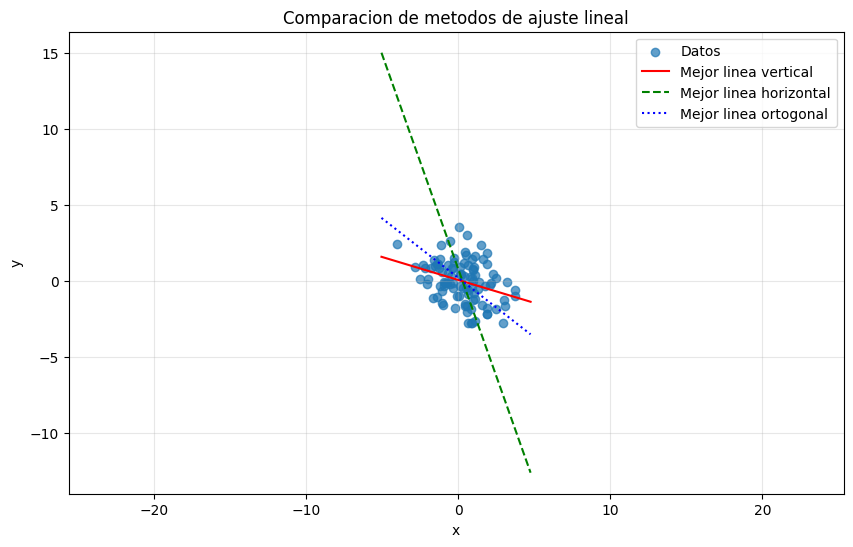

In [8]:

def generar_datos(n=100):
    """Genera datos lineales con ruido"""
    np.random.seed(42)  # Para reproducibilidad
    C = np.array([[3, -1], [-1, 2]])  # Matriz de covarianza
    m = np.random.randn(2)  # Media
    # Generar datos aleatorios con la matriz de covarianza C y media m
    data = m + np.random.randn(n, 2) @ np.linalg.cholesky(C).T  # Correcto: Z @ L.T da covarianza L @ L.T = C
    x = data[:, 0]
    y = data[:, 1]
    return x, y

def encontrar_mejor_linea_errores_verticales(x, y):
    """Encuentra la mejor linea y=mx+n minimizando distancias verticales"""
    # Ecuaciones normales: A^T A [m; n] = A^T y
    # Matriz de diseno A_d con columnas [x, 1]
    A_d = np.column_stack([x, np.ones(len(x))])
    params = np.linalg.solve(A_d.T @ A_d, A_d.T @ y)
    m, n = params[0], params[1]
    # Verificacion de equivalencia con lstsq
    params_lstsq, _, _, _ = np.linalg.lstsq(A_d, y, rcond=None)
    assert np.allclose(params, params_lstsq), "Ecuaciones normales y lstsq difieren"
    return m, n

def encontrar_mejor_linea_errores_horizontales(x, y):
    """Encuentra la mejor linea y=mx+n minimizando distancias horizontales"""
    # Minimizar distancias horizontales equivale a ajustar x = ay + c
    # Usamos la funcion anterior intercambiando roles de x e y
    a, c = encontrar_mejor_linea_errores_verticales(y, x)
    # Convertir x = ay + c  =>  y = (1/a)x - (c/a)
    m = 1.0 / a
    n = -c / a
    return m, n

def encontrar_mejor_linea_errores_ortogonales(x, y):
    """Encuentra la mejor linea y=mx+n minimizando distancias ortogonales"""
    # PCA: centrar datos y hallar la primera componente principal
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    data = np.column_stack([x - x_mean, y - y_mean])
    # Matriz de covarianza empirica
    C = data.T @ data / len(x)
    # Autovector del autovalor maximo = direccion de maxima varianza
    eigenvalues, eigenvectors = np.linalg.eigh(C)
    principal = eigenvectors[:, np.argmax(eigenvalues)]
    # La direccion [v0, v1] define la pendiente m = v1/v0
    m = principal[1] / principal[0]
    n = y_mean - m * x_mean
    return m, n

def visualizar_datos_lineas(x, y, m1, n1, m2, n2, m3, n3):
    """Visualiza los datos y las lineas ajustadas"""
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.7, label='Datos')
    x_plot = np.linspace(min(x)-1, max(x)+1, 100)
    plt.plot(x_plot, m1*x_plot + n1, 'r-', label='Mejor linea vertical')
    plt.plot(x_plot, m2*x_plot + n2, 'g--', label='Mejor linea horizontal')
    plt.plot(x_plot, m3*x_plot + n3, 'b:', label='Mejor linea ortogonal')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.axis('equal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Comparacion de metodos de ajuste lineal')
    plt.show()

# Aplicar
x, y = generar_datos()
m1, n1 = encontrar_mejor_linea_errores_verticales(x, y)
m2, n2 = encontrar_mejor_linea_errores_horizontales(x, y)
m3, n3 = encontrar_mejor_linea_errores_ortogonales(x, y)
print(f"Vertical:   y = {m1:.4f}x + {n1:.4f}")
print(f"Horizontal: y = {m2:.4f}x + {n2:.4f}")
print(f"Ortogonal:  y = {m3:.4f}x + {n3:.4f}")
visualizar_datos_lineas(x, y, m1, n1, m2, n2, m3, n3)


##### Aplicación: Ajuste de otras curvas
Mínimos cuadrados no se limita a líneas rectas. En este ejercicio, exploraremos el ajuste de polinomios y otros modelos a datos no lineales.
Aunque existen funciones como `np.polyfit()` y `scipy.optimize.curve_fit()` que facilitan el ajuste de polinomios y funciones no lineales, es importante entender cómo funcionan internamente. En este ejercicio, implementaremos el ajuste de polinomios de diferentes grados mediante mínimos cuadrados directamente.

Para ajustar un polinomio de grado `n` a un conjunto de datos `(x, y)`, se construye la matriz de diseño `X` donde cada fila es `[x_i^0, x_i^1, ..., x_i^n]`. Estas matrices son conocidas como matrices de Vandermonde. Luego, se resuelve el sistema `X @ a = y` para encontrar los coeficientes `a` del polinomio.  Por ejemplo, para un polinomio de grado 2, la matriz de diseño sería:
$$ X = \begin{pmatrix} x_1^2 & x_1 & 1 \\ x_2^2 & x_2 & 1 \\ \vdots & \vdots & \vdots \\ x_n^2 & x_n & 1 \end{pmatrix}$$

**Ejercicio L2.3.4**: Complete el código provisto para ajustar polinomios de diferentes grados a datos no lineales.  Aplique el ajuste a datos de caída libre con distintos niveles de ruido.  Discuta las diferencias entre los ajustes con polinomios de grado 1, 2 y 3. ¿Qué grado es el más adecuado? ¿Por qué? Discuta las diferencias entre los ajustes con ruido bajo y alto. ¿Qué ocurre?  Para el caso del polinomio de grado 2, imprima el valor de la aceleración gravitacional `g` y discuta si es razonable.  

Ruido bajo (std=0.1):
  Grado 1: [ 49.05137933 -80.94152371]
  Grado 2: [ 4.90573302 -0.00595091 -0.00518764]  =>  g estimada = 9.8115 m/s^2
  Grado 3: [-1.02042684e-03  4.92103943e+00 -6.68693789e-02  4.42980172e-02]


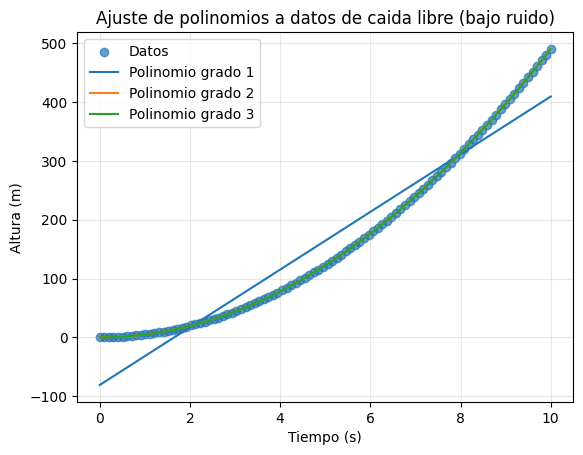


Ruido alto (std=2):
  Grado 1: [ 49.07758653 -81.26986813]
  Grado 2: [ 4.91966047 -0.11901812 -0.1037527 ]  =>  g estimada = 9.8393 m/s^2
  Grado 3: [-0.02040854  5.22578852 -1.33738758  0.88596034]


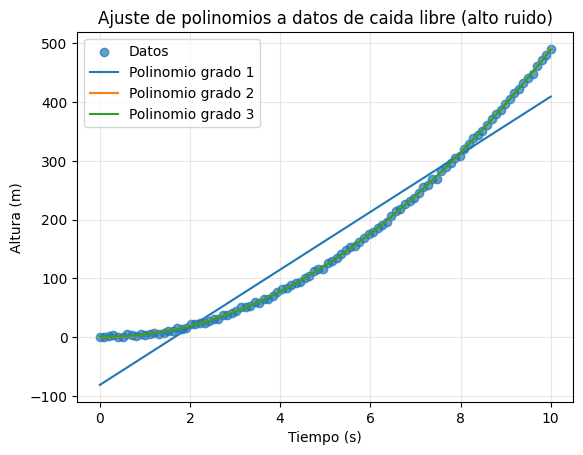

In [9]:

def generar_matriz_vandermonde(x, grado):
    """Genera la matriz de Vandermonde para un polinomio de grado dado"""
    n = len(x)
    X = np.zeros((n, grado + 1))
    # Columna j contiene x^(grado-j): orden decreciente compatible con np.polyval
    for j in range(grado + 1):
        X[:, j] = x ** (grado - j)
    # Verificacion contra np.vander()
    assert np.allclose(X, np.vander(x, grado + 1)), "La matriz no coincide con np.vander()"
    return X

def ajustar_polinomio(x, y, grado):
    """Ajusta un polinomio de grado dado a los datos (x, y)"""
    X = generar_matriz_vandermonde(x, grado)
    # lstsq resuelve el sistema sobredeterminado X @ a = y en sentido de minimos cuadrados.
    # Los coeficientes quedan en orden decreciente [a_n, ..., a_1, a_0], compatible con polyval.
    coeficientes, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return coeficientes

def graficar_ajustes(x, y, lista_coeficientes):
    """Grafica los datos y el polinomio ajustado"""
    plt.scatter(x, y, label='Datos', alpha=0.7)
    for coeficientes in lista_coeficientes:
        x_plot = np.linspace(min(x), max(x), 100)
        y_plot = np.polyval(coeficientes, x_plot)
        plt.plot(x_plot, y_plot, label=f'Polinomio grado {len(coeficientes)-1}')


def generar_datos_caida_libre(n=100, std_ruido=1):  
    """Genera datos de caida libre con ruido"""
    np.random.seed(42)
    t = np.linspace(0, 10, n)  # Tiempo en segundos
    g = 9.81  # Aceleracion gravitacional
    h = 0.5 * g * t**2 + np.random.randn(n) * std_ruido  # Altura con ruido
    return t, h

# Ruido bajo: std_ruido=0.1
t, h = generar_datos_caida_libre(std_ruido=0.1)
coeficientes_1 = ajustar_polinomio(t, h, 1)
coeficientes_2 = ajustar_polinomio(t, h, 2)
coeficientes_3 = ajustar_polinomio(t, h, 3)

print("Ruido bajo (std=0.1):")
print(f"  Grado 1: {coeficientes_1}")
print(f"  Grado 2: {coeficientes_2}  =>  g estimada = {2*coeficientes_2[0]:.4f} m/s^2")
print(f"  Grado 3: {coeficientes_3}")

graficar_ajustes(t, h, [coeficientes_1, coeficientes_2, coeficientes_3])
plt.title('Ajuste de polinomios a datos de caida libre (bajo ruido)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Altura (m)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Ruido alto: std_ruido=2
t, h = generar_datos_caida_libre(std_ruido=2)
coeficientes_1 = ajustar_polinomio(t, h, 1)
coeficientes_2 = ajustar_polinomio(t, h, 2)
coeficientes_3 = ajustar_polinomio(t, h, 3)

print("\nRuido alto (std=2):")
print(f"  Grado 1: {coeficientes_1}")
print(f"  Grado 2: {coeficientes_2}  =>  g estimada = {2*coeficientes_2[0]:.4f} m/s^2")
print(f"  Grado 3: {coeficientes_3}")

graficar_ajustes(t, h, [coeficientes_1, coeficientes_2, coeficientes_3])
plt.title('Ajuste de polinomios a datos de caida libre (alto ruido)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Altura (m)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3. Visualización del espacio de soluciones
En el caso de sistemas indeterminados $Ax=b$, la solución de mínimos cuadrados (exacta o no), no es única. En este ejercicio, exploraremos cómo visualizar el espacio de todas las soluciones equivalentes (es decir, todos los vectores $x$ que satisface $Ax=v$ con $v$ la proyección de $b$ sobre el espacio columna de $A$) y verificar que la solución de la pseudoinversa es la de mínima norma.

**Ejercicio L2.3.5**: 
Considere el sistema indeterminado (2 ecuaciones, 3 incógnitas) de rango fila completo dado abajo:
$$A = \begin{pmatrix} 1 & 2 & 1 \\ 2 & 3 & 4 \end{pmatrix}, \quad b = \begin{pmatrix} 5 \\ 10 \end{pmatrix}$$

En este caso existen infinitas soluciones exactas $Ax=b$.  Complete el código para encontrar todo el conjunto de soluciones y visualizarlo.  Verifique que la solución de mínimos cuadrados (pseudoinversa) es la de mínima norma.  

Solucion arbitraria: [0. 2. 1.]
Ax=b: True
Norma de la solucion arbitraria: 2.2361
La direccion nula son vectores proporcionales a: [-0.91287093  0.36514837  0.18257419]
Solucion 1: [-4.62969531  3.85187812  1.92593906]
Ax=b: True
Norma de la solucion 1: 6.3230
Solucion 2: [1.27602204 1.48959118 0.74479559]
Ax=b: True
Norma de la solucion 2: 2.0981
Solucion 3: [-0.08988172  2.03595269  1.01797634]
Ax=b: True
Norma de la solucion 3: 2.2780
Solucion pseudoinversa: [0.83333333 1.66666667 0.83333333]
Ax=b: True
Norma de la solucion pseudoinversa: 2.0412
La pseudoinversa tiene norma menor a todas las otras: True


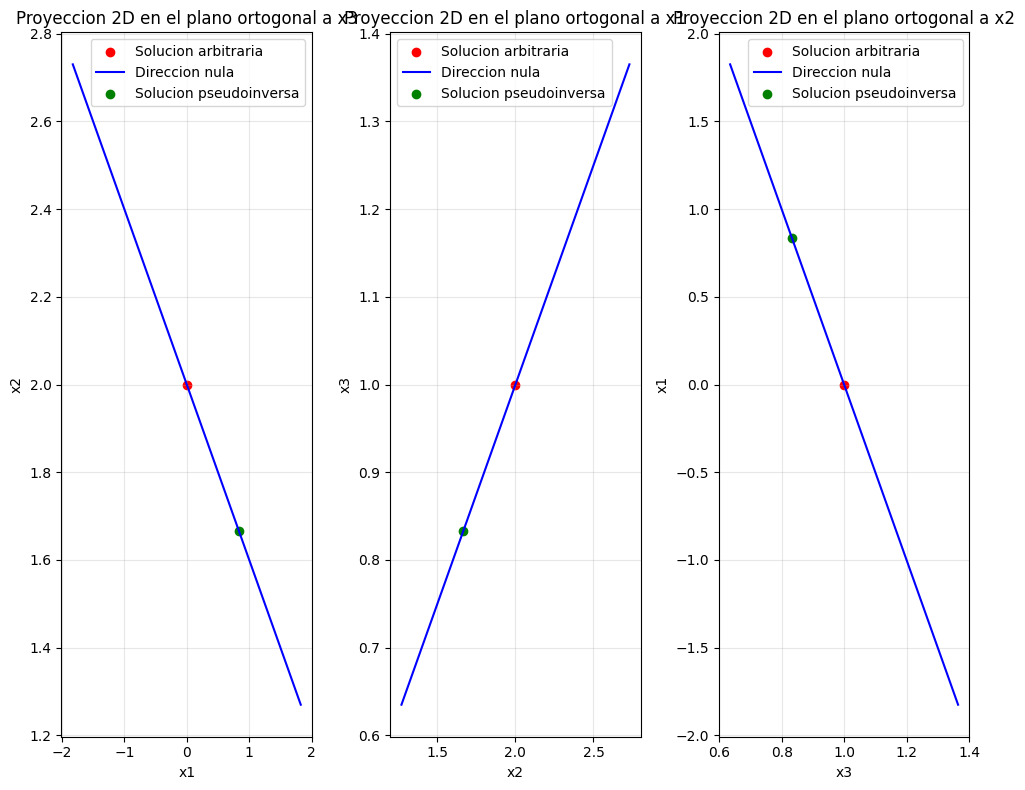

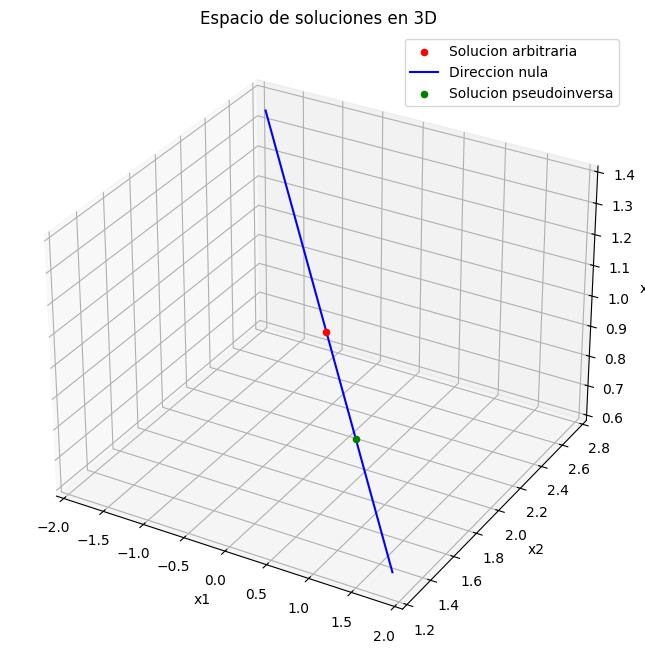

In [10]:

def visualizar_espacio_soluciones(x_arbitraria, vector_nulo, x_pinv):
    """Visualiza el espacio de soluciones mediante proyecciones 2D y 3D"""
    fig = plt.figure(figsize=(10, 8))
    ejes = ['x1', 'x2', 'x3']
    for i in range(3):
        ax = fig.add_subplot(131 + i)
        ax.set_title(f'Proyeccion 2D en el plano ortogonal a {ejes[np.mod(i+2, 3)]}')
        ax.scatter(x_arbitraria[np.mod(i, 3)], x_arbitraria[np.mod(i+1, 3)], color='r', label='Solucion arbitraria')
        largo = 2
        ax.plot([x_arbitraria[np.mod(i, 3)]-largo*vector_nulo[np.mod(i, 3)], x_arbitraria[np.mod(i, 3)]+largo*vector_nulo[np.mod(i, 3)]],
                [x_arbitraria[np.mod(i+1, 3)]-largo*vector_nulo[np.mod(i+1, 3)], x_arbitraria[np.mod(i+1, 3)]+largo*vector_nulo[np.mod(i+1, 3)]],
                color='b', label='Direccion nula')
        ax.scatter(x_pinv[np.mod(i, 3)], x_pinv[np.mod(i+1, 3)], color='g', label='Solucion pseudoinversa')
        ax.set_xlabel(f'{ejes[np.mod(i, 3)]}')
        ax.set_ylabel(f'{ejes[np.mod(i+1, 3)]}')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title('Espacio de soluciones en 3D')
    ax.scatter(x_arbitraria[0], x_arbitraria[1], x_arbitraria[2], color='r', label='Solucion arbitraria')
    ax.plot([x_arbitraria[0]-largo*vector_nulo[0], x_arbitraria[0]+largo*vector_nulo[0]],
            [x_arbitraria[1]-largo*vector_nulo[1], x_arbitraria[1]+largo*vector_nulo[1]],
            [x_arbitraria[2]-largo*vector_nulo[2], x_arbitraria[2]+largo*vector_nulo[2]],
            color='b', label='Direccion nula')
    ax.scatter(x_pinv[0], x_pinv[1], x_pinv[2], color='g', label='Solucion pseudoinversa')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('x3')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

A = np.array([[1, 2, 1],
              [2, 3, 4]])
b = np.array([5, 10])

# Solucion arbitraria con x_1=0: resolver el subsistema 2x2 para [x_2, x_3]
x_23 = np.linalg.solve(A[:, 1:], b)
x_arbitraria = np.concatenate([[0.0], x_23])
print(f"Solucion arbitraria: {x_arbitraria}")
print(f"Ax=b: {np.allclose(A @ x_arbitraria, b)}")
print(f"Norma de la solucion arbitraria: {np.linalg.norm(x_arbitraria):.4f}")

# Subespacio nulo de A (1D, rango=2, 3 incognitas): ultimo vector singular derecho (SVD)
_, _, Vt = np.linalg.svd(A)
vector_nulo = Vt[-1]  # Vector correspondiente al valor singular mas pequeno (=0)
print(f"La direccion nula son vectores proporcionales a: {vector_nulo}")
assert np.allclose(A @ vector_nulo, 0, atol=1e-10), "El vector nulo no satisface Av=0"

# Generar 3 soluciones AL AZAR a partir de la solucion arbitraria y el vector nulo
np.random.seed(7)
t1, t2, t3 = np.random.randn(3) * 3
x_1 = x_arbitraria + t1 * vector_nulo
x_2 = x_arbitraria + t2 * vector_nulo
x_3 = x_arbitraria + t3 * vector_nulo
print(f"Solucion 1: {x_1}")
print(f"Ax=b: {np.allclose(A @ x_1, b)}")
print(f"Norma de la solucion 1: {np.linalg.norm(x_1):.4f}")
print(f"Solucion 2: {x_2}")
print(f"Ax=b: {np.allclose(A @ x_2, b)}")
print(f"Norma de la solucion 2: {np.linalg.norm(x_2):.4f}")
print(f"Solucion 3: {x_3}")
print(f"Ax=b: {np.allclose(A @ x_3, b)}")
print(f"Norma de la solucion 3: {np.linalg.norm(x_3):.4f}")

# Solucion de minima norma: pseudoinversa
x_pinv = np.linalg.pinv(A) @ b
print(f"Solucion pseudoinversa: {x_pinv}")
print(f"Ax=b: {np.allclose(A @ x_pinv, b)}")
print(f"Norma de la solucion pseudoinversa: {np.linalg.norm(x_pinv):.4f}")

# Verificar que la pseudoinversa tiene la norma minima entre todas las soluciones
norms = [np.linalg.norm(x_arbitraria), np.linalg.norm(x_1),
         np.linalg.norm(x_2), np.linalg.norm(x_3)]
print(f"La pseudoinversa tiene norma menor a todas las otras: {all(np.linalg.norm(x_pinv) <= n for n in norms)}")

visualizar_espacio_soluciones(x_arbitraria, vector_nulo, x_pinv)
